Import the libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import joblib


load final dataset

In [3]:
data = pd.read_csv('../DATA1/final_dataset.csv')
data.head()

#feature_pipeline = joblib.load('../models1/feature_pipeline.pkl')


,match_id,batsman,runs,career_avg_runs,recent_form,venue,venue_avg_runs,opponent,opponent_avg,recent_form_5,matches_played,run_consistency,fifty_rate,next_match_runs
0,548346,A Ashish Reddy,10,12.173913,12.173913,Wankhede Stadium,10.000000,Mumbai Indians,13.500000,10.00,1,17.577621,0.0,3.0
1,548352,A Ashish Reddy,3,12.173913,12.173913,"MA Chidambaram Stadium, Chepauk",19.500000,Chennai Super Kings,15.000000,6.50,2,4.949747,0.0,8.0
2,548359,A Ashish Reddy,8,12.173913,12.173913,"Rajiv Gandhi International Stadium, Uppal",8.454545,Kings XI Punjab,12.333333,7.00,3,3.605551,0.0,10.0
3,548373,A Ashish Reddy,10,12.173913,12.173913,"Rajiv Gandhi International Stadium, Uppal",8.454545,Rajasthan Royals,12.333333,7.75,4,3.304038,0.0,4.0
4,548376,A Ashish Reddy,4,12.173913,7.000000,"Rajiv Gandhi International Stadium, Uppal",8.454545,Royal Challengers Bangalore,11.000000,7.00,5,3.316625,0.0,7.0


Preprocessing Pipeline

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a NEW preprocessing pipeline
feature_pipeline = Pipeline([
    ('scaler', StandardScaler())
])


FEATURES & TARGET

In [5]:
features = [
    'career_avg_runs',
    'recent_form',
    'recent_form_5',
    'venue_avg_runs',
    'opponent_avg',
    'matches_played',
    'run_consistency',
    'fifty_rate'
]
target = 'next_match_runs'

X = data[features]
y = data[target]


TIME-AWARE TRAIN-TEST SPLIT

In [6]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]
print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (12673, 8)
Test : (3169, 8)


Apply Preprocessing

In [6]:
# FIT pipeline on NEW feature set
X_train_scaled = feature_pipeline.fit_transform(X_train)
X_test_scaled  = feature_pipeline.transform(X_test)


In [7]:
import joblib

joblib.dump(feature_pipeline, '../models1/feature_pipeline.pkl')


['../models1/feature_pipeline.pkl']

Baseline Prediction

In [8]:
baseline_pred = X_test['recent_form']


Baseline Evaluation

In [9]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)


Baseline MAE: 16.50651784137502
Baseline RMSE: 22.259986277629146
Baseline R2: -0.004690192792173642


RANDOM FOREST MODEL

In [10]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

EVALUATE RANDOM FOREST MODEL

In [11]:
rf_pred = rf_model.predict(X_test_scaled)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)


Random Forest MAE: 16.22939966666166
Random Forest RMSE: 21.265204385164278
Random Forest R2: 0.08310099643245195


Import XGBoost

In [13]:
from xgboost import XGBRegressor


XGBOOST MODEL

In [14]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=5, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

In [15]:
xgb_pred = xgb_model.predict(X_test_scaled)


Evaluate XGBoost

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)


XGBoost MAE: 15.673820785334073
XGBoost RMSE: 20.81080382422039
XGBoost R2: 0.1218674228371921


SAVE THE MODEL

In [17]:
import joblib

joblib.dump(xgb_model, '../models1/xgb_model.joblib')


['../models1/xgb_model.joblib']

IMPORT LGBM

In [18]:
from lightgbm import LGBMRegressor


LGBM MODEL

In [20]:
lgbm_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgbm_model.fit(X_train_scaled, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000372 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1988
[LightGBM] [Info] Number of data points in the train set: 12673, number of used features: 8
[LightGBM] [Info] Start training from score 20.130435


LGBMRegressor(random_state=42)

EVALUATE LGBM

In [21]:
lgbm_pred = lgbm_model.predict(X_test_scaled)

lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_r2 = r2_score(y_test, lgbm_pred)

print("LightGBM MAE:", lgbm_mae)
print("LightGBM RMSE:", lgbm_rmse)
print("LightGBM R2:", lgbm_r2)


LightGBM MAE: 15.674208613989482
LightGBM RMSE: 20.929624845099056
LightGBM R2: 0.11181125385145196


In [22]:
joblib.dump(lgbm_model, '../models1/lgbm_model.joblib')


['../models1/lgbm_model.joblib']

HYPERPARAMETER TUNING

In [23]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}

grid = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error'
)

grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)


Best Params: {'max_depth': 3, 'n_estimators': 50}


MODEL COMPARISION

In [24]:
model_comparison = pd.DataFrame({
    'Model': [
        'Baseline (Rolling Avg)',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],
    'MAE': [
        baseline_mae,
        rf_mae,
        xgb_mae,
        lgbm_mae
    ],
    'RMSE': [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        lgbm_rmse
    ],
    'R2 Score': [
        baseline_r2,
        rf_r2,
        xgb_r2,
        lgbm_r2
    ]
})

model_comparison


,Model,MAE,RMSE,R2 Score
0,Baseline (Rolling Avg),16.506518,22.259986,-0.004690
1,Random Forest,16.229400,21.265204,0.083101
2,XGBoost,15.673821,20.810804,0.121867
3,LightGBM,15.674209,20.929625,0.111811


IMPORT SHAP

In [25]:
import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


CREATE SHAP EXPLAINER

In [26]:
# Create SHAP explainer
explainer = shap.Explainer(xgb_model, X_train_scaled)

# Calculate SHAP values
shap_values = explainer(X_train_scaled)


 98%|===================| 12461/12673 [00:22<00:00]        

SHAP SUMMARY PLOT

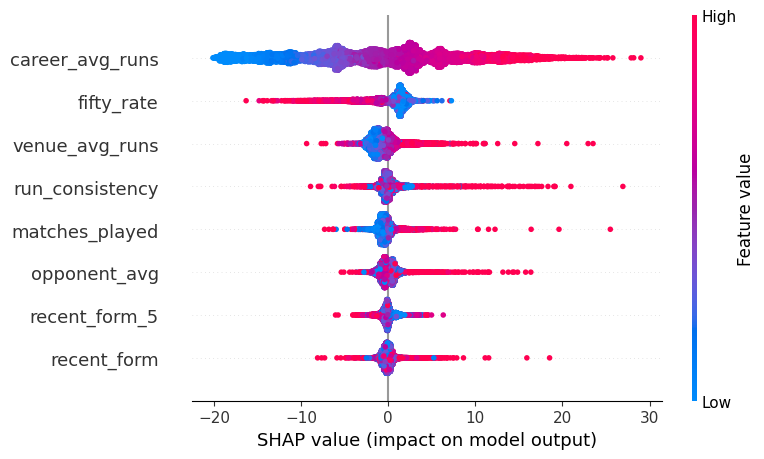

In [27]:
shap.summary_plot(shap_values, X_train, feature_names=features)


OPTIONAL BAR PLOT

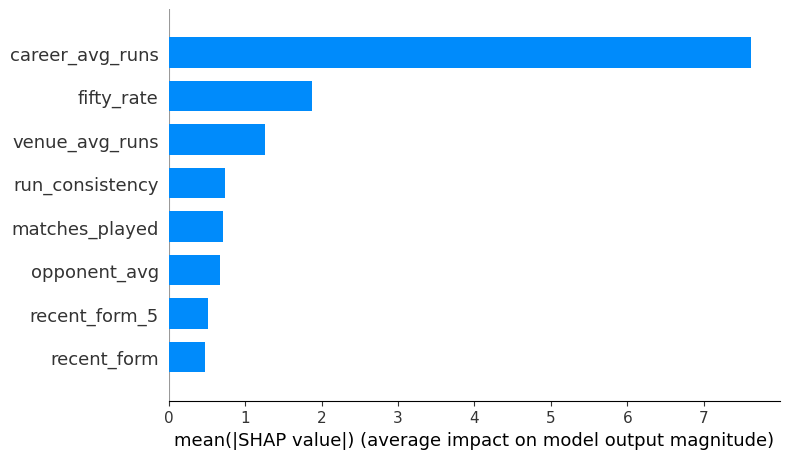

In [28]:
shap.summary_plot(shap_values, X_train, feature_names=features, plot_type="bar")


In [29]:
print("FINAL MODEL: XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)


FINAL MODEL: XGBoost
MAE: 15.673820785334073
RMSE: 20.81080382422039
R2: 0.1218674228371921


Bowler Dataset Creation & Wicket Model Training

Load Deliveries Dataset

In [30]:
import pandas as pd

original_data = pd.read_csv("../DATA1/deliveries.csv")

original_data.head()


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [31]:
# Create match-level bowler data

bowler_df = original_data.groupby(
    ["match_id", "bowler", "batting_team"]
).agg({
    "is_wicket": "sum"
}).reset_index()

# Rename columns properly
bowler_df.rename(columns={
    "batting_team": "opponent",
    "is_wicket": "wickets"
}, inplace=True)

bowler_df.head()


,match_id,bowler,opponent,wickets
0,335982,AA Noffke,Kolkata Knight Riders,1
1,335982,AB Agarkar,Royal Challengers Bangalore,3
2,335982,AB Dinda,Royal Challengers Bangalore,2
3,335982,CL White,Kolkata Knight Riders,0
4,335982,I Sharma,Royal Challengers Bangalore,1


In [32]:
bowler_df["career_wicket_avg"] = bowler_df.groupby("bowler")["wickets"].transform("mean")


In [33]:
bowler_df["recent_wickets"] = bowler_df.groupby("bowler")["wickets"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)


In [34]:
bowler_df["opponent_wicket_avg"] = bowler_df.groupby(
    ["bowler", "opponent"]
)["wickets"].transform("mean")


In [35]:
bowler_df["next_match_wickets"] = bowler_df.groupby("bowler")["wickets"].shift(-1)

bowler_df.dropna(inplace=True)

bowler_df.head()


,match_id,bowler,opponent,wickets,career_wicket_avg,recent_wickets,opponent_wicket_avg,next_match_wickets
1,335982,AB Agarkar,Royal Challengers Bangalore,3,0.785714,3.0,1.000000,2.0
2,335982,AB Dinda,Royal Challengers Bangalore,2,1.093333,2.0,1.375000,1.0
3,335982,CL White,Kolkata Knight Riders,0,0.166667,0.0,0.000000,0.0
4,335982,I Sharma,Royal Challengers Bangalore,1,0.872727,1.0,0.733333,1.0
5,335982,JH Kallis,Kolkata Knight Riders,1,0.831461,1.0,1.000000,0.0


In [36]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import joblib

X_bowl = bowler_df[[
    "career_wicket_avg",
    "recent_wickets",
    "opponent_wicket_avg"
]]

y_bowl = bowler_df["next_match_wickets"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bowl, y_bowl, test_size=0.2, random_state=42
)

wicket_model = XGBRegressor(random_state=42)
wicket_model.fit(X_train_b, y_train_b)

print("Wicket model trained successfully")


Wicket model trained successfully


In [37]:
joblib.dump(wicket_model, "../models1/wicket_model.joblib")

bowler_df.to_csv("../DATA1/bowler_dataset.csv", index=False)

print("Saved successfully")


Saved successfully
